## Setup

In [1]:
import numpy as np
from matplotlib import pyplot as plt

Definiere die Funktion $f$ und deren Auswertungsstelle $x_0$ (`x`)

In [2]:
f = np.exp
df = np.exp
x = 0
h_0 = 0.1

Parameter für die Auswertung und Darstellung:

In [3]:
n = 60
h = h_0 * 0.5 ** np.arange(n)

## Approximation
Approximiere die Ableitung mithilfe des imaginären Schritts und des Differenzenquotienten als Vergleichswerte. 

In [4]:
approx = (f(x + h) - f(x)) / h
i_approx = (f(x + 1j*h) - f(x)).imag / h
d2_approx = (f(x + h) - f(x - h)) / (2 * h)

# rel. Fehler
actual = df(x)
rel_error = abs((approx - actual) / actual)
i_rel_error = abs((i_approx - actual) / actual)
d2_rel_error = abs((d2_approx - actual) / actual)

Nun berechnen wir nach dem Richardson-Schema (_Skript Bsp 1.1.20_) mehrere Abstufungen von $R_{k, k}$ **in place**.
Vorgehen: Ersetze einen Teilvektor (`d[i:]`='Das $i$-te bis zum letzten Element) mit der Berechnung rechts, wobei die Indexe um $1$ verschoben sind, um benachbarte Elemente zu subtrahieren. Da mit jeder Iteration ein Element weniger verändert wird ($i$ wächst), steht am Ende genau die Diagonale des Richardson-Schemas ($R_{i, i}$) im Vektor $d$.

In [5]:
d = (f(x+h) - f(x-h)) * 0.5 / h
for i in range(1, n):
    d[i:] = ((4**i) * d[i:] - d[i-1:-1]) / (4**i - 1)

r_rel_error = abs((d - actual) / actual)

## Plot
plotte den relativen Fehler:

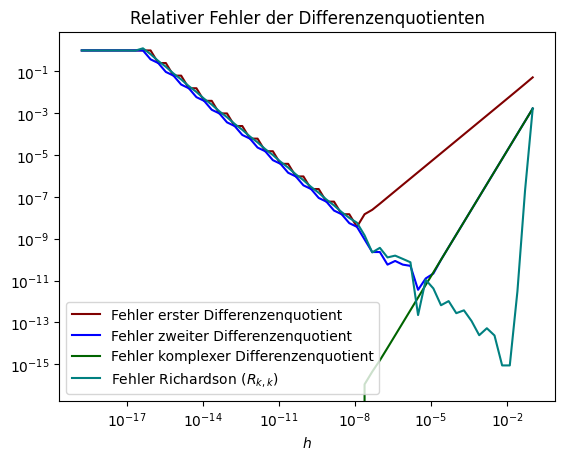

In [6]:
plt.title("Relativer Fehler der Differenzenquotienten")
# plt.loglog(h, h/2, color="#dddddd", label=r"$\frac{h}{2}$")
plt.loglog(h, rel_error, color="maroon", label="Fehler erster Differenzenquotient")
# plt.loglog(h, (h**2)/4, color="#eeeeee", label=r"$\frac{h^2}{4}$")
plt.loglog(h, d2_rel_error, color="blue", label="Fehler zweiter Differenzenquotient")
plt.loglog(h, i_rel_error, color="darkgreen", label="Fehler komplexer Differenzenquotient")
plt.loglog(h, r_rel_error, color="teal", label=r"Fehler Richardson ($R_{k, k})$")
plt.legend()
plt.xlabel(r"$h$")
plt.show() 

Wie hier nun zu erkennen ist, konvergiert das Richardson-Schema **viel** schneller, als 'normale' Differenzenquotienten. Sie leiden allerdings ebenfalls unter Auslöschung. 